# خوارزمية CA2C

##
خوارزمية **CA2C** (Complementary Label Adversarial Disambiguation) هي منهجية متقدمة في التعلم العميق تهدف إلى حل واحدة من أكبر مشاكل الذكاء الاصطناعي: **كيف نجعل النموذج يتعلم بشكل صحيح إذا كانت البيانات التي يتعلم منها تحتوي على  Noisy Labels؟**

في العالم الحقيقي، نادراً ما تكون البيانات مصنفة بنسبة 100% بشكل صحيح فأتت خوارزمية CA2C تحل هذه المشكلة بدلاً من التخلص من البيانات المشوشة.

## كيف تعمل الخوارزمية؟ 
تعتمد الخوارزمية على فكرة **Complementary Learning** وتعمل من خلال المكونات الثلاثة التالية:

1. **النموذج الإيجابي (P-model):** يحاول التصنيف بالطريقة التقليدية (تحديد ما هي الصورة).
2. **النموذج السلبي (N-model):** لا يحاول معرفة ما هي الصورة، بل يتعلم **ما هي الفئات التي لا تنتمي إليها الصورة**  هذا يسمى التعلم من التسميات المتممة، وهو آمن جداً لأن احتمالية أن تكون التسمية المتممة خاطئة ضعيفة جداً.
3. **بنك الذاكرة التراكمي (Memory Bank):** هو الذي يربط بين النموذجين. يسجل التوقعات التاريخية لكل صورة على حدة عبر كل Epochs. 

**آلية التدريب:**
يبدأ التدريب بمرحلة **(Warm-up)** لتأسيس معرفة أولية للشبكات وتعبئة بنك الذاكرة.
 ثم تبدأ ** (Robust Phase)**، حيث يقوم الـ P-model بتوليد تسميات متممة موثوقة ليقوم الـ N-model بالتدرب عليها
  وفي نفس الوقت يستخدم النموذجان بنك الذاكرة لفلترة ال noise واختيار التسميات الأكثر منطقية رياضياً لتصحيح مسار التدريب.

قمنا بتعريف المتغيرات الاساسية التي تتحكم بالتدريب

K  اعلى الفئات المرشحة

LAMBDA معامل التوازن 

TEMPERATURE هذا يمنع النموذج من الثقة المفرطة في قراراته المبدئية التي قد تكون مبنية على تسميات خاطئة.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE      = 128
NUM_EPOCHS      = 300
WARM_UP_EPOCHS  = 60
LEARNING_RATE   = 0.01
MOMENTUM        = 0.9
WEIGHT_DECAY    = 5e-4
NUM_CLASSES     = 100
K               = 2    
LAMBDA          = 0.99 
TEMPERATURE     = 1.5
print(f'K={K}, lambda={LAMBDA}')

K=2, lambda=0.99


### Data Augmentation & Noisy Dataset
بداية اول شي سنعمل عليه بعد تحميل الداتا 
 ولحتى نضمن ان المودبل عم يفهم الصور ولا يعمل على طريقة البصم
 
  لنتجنب مشكلة Overfitting هو أننا طبقنا عليها بعض تقنيات زيادة البيانات
  
   مثل القص العشوائي والقلب الأفقي هكذا نكون رفعنا تنوع الصور وجعلنا الموديل أقوى وأكثر مرونة بالتعرف على الأجسام بوضعيات مختلفة.

أما بالنسبة النموذج 
بالنسبة للمعمارية اللتي بنينا عليها الخوارزمية فالورقة البحثية الأساسية  CA2C اعتمدت على بنيتين رئيسيتين لاختبار وتجربة الخوارزمية، ResNet و CNN من 7 طبقات
نحن بمشروعنا اخترنا نطبق الخوارزمية بالاعتماد على بنية CNN كونها عملية


In [2]:
class NoisyDataset(Dataset):

    def __init__(self, images, labels, augment=False):
        self.images  = images
        self.labels  = labels
        self.augment = augment
        self.n       = len(labels)

    def __len__(self): return self.n

    def _flip(self, img):
        return torch.flip(img, dims=[2]) if torch.rand(1).item() > 0.5 else img

    def _crop(self, img, pad=4):
        c, h, w = img.shape
        padded = torch.zeros(c, h+2*pad, w+2*pad)
        padded[:, pad:pad+h, pad:pad+w] = img
        t = torch.randint(0, 2*pad+1, (1,)).item()
        l = torch.randint(0, 2*pad+1, (1,)).item()
        return padded[:, t:t+h, l:l+w]

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        if self.augment:
            img = self._crop(img)
            img = self._flip(img)
        return img, int(self.labels[idx]), idx


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if pool: layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class CNN7(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   64,  pool=False),
            ConvBlock(64,  64,  pool=True),
            ConvBlock(64,  128, pool=False),
            ConvBlock(128, 128, pool=True),
            ConvBlock(128, 196, pool=False),
            ConvBlock(196, 196, pool=True),
        )
        self.classifier = nn.Sequential(
            nn.Linear(196 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

_m = CNN7(10)
_x = torch.randn(4, 3, 32, 32)
print(f'CNN7: {_x.shape} -> {_m(_x).shape}, params={sum(p.numel() for p in _m.parameters()):,}')
del _m, _x


CNN7: torch.Size([4, 3, 32, 32]) -> torch.Size([4, 10]), params=1,638,506


## Diagnoses

بما إننا ندرب الموديل على بيانات مشوشة ولفترة طويلة، فكان من الضروري إضافة دوال مراقبة للتأكد ما اذا كان التدريب في  بالمسار الصحيح. 

  حالة معلومات الذاكرة: يتأكد من ان المعلومات عم تتحدث ولا يحدث فيها تكرار أو انحياز لفئة معينة. 

 استقرار Loss: بيراقب القيم للتأكد من ان الموديل ما عم ينهار ولا يضيع وقته بتدريب غير مجدي.


In [ ]:
def diagnose_candidate_count(candidate_count, epoch, phase):
    if epoch % 10 != 0:
          return True

    with torch.no_grad():

        filled = (candidate_count.sum(dim=1) > 0).sum().item()
        total = candidate_count.size(0)

        counts_per_class = candidate_count.sum(dim=0)
        mean_count = counts_per_class.mean().item()
        std_count = counts_per_class.std().item()
        max_count = counts_per_class.max().item()
        min_count = counts_per_class.min().item()

        top_classes = counts_per_class.argsort(descending=True)[:3]
        top_values = counts_per_class[top_classes]

        total_counts = counts_per_class.sum().item()
        bias_ratio = (top_values[0].item() / total_counts * 100) if total_counts > 0 else 0

        print(f"\n[Ep{epoch:3d} {phase:8s}] Candidate Count Stats:")
        print(f"Filled samples: {filled}/{total} ({100*filled/total:.1f}%)")
        print(f"Mean: {mean_count:.1f}, Std: {std_count:.1f}, Range: [{min_count:.0f}, {max_count:.0f}]")
        print(f"Top-3 classes: {top_classes.cpu().numpy()} with counts {top_values.cpu().numpy()}")

        if bias_ratio > 30:
            print(f" التوقعات تغلب حول فئة وحدة(>{bias_ratio:.1f}%)")
            return False


def diagnose_robust_phase(p_model, n_model, loader, device, candidate_count, epoch):

    p_model.eval()
    n_model.eval()

    with torch.no_grad():
        sample_count = 0
        total_nl_loss = 0.0
        comp_mask_sparsity = []
        y_soft_entropy = []

        for imgs, labels, indices in loader:
            imgs = imgs.to(device)
            indices = indices.to(device)
            B = imgs.size(0)

            logits_p = p_model(imgs)
            logits_n = n_model(imgs)

            # Complementary mask
            comp_mask = get_comp_from_p(logits_p, K)

            # Count complement labels
            comp_per_sample = comp_mask.sum(dim=1)
            comp_mask_sparsity.append(comp_per_sample)

            # NL loss components — MATCH THE ACTUAL TRAINING
            probs_n = F.softmax(logits_n, dim=1)
            log_one_minus_p = torch.log(torch.clamp(1.0 - probs_n, min=1e-8))

            # Sum over complementary labels for each sample
            loss_per_sample = torch.sum(comp_mask * log_one_minus_p, dim=1)
            total_nl_loss += (-loss_per_sample).sum().item()  # Match -torch.mean()

            # Y_soft entropy (how "peaked" is the distribution)
            counts = candidate_count[indices].float()
            count_sum = counts.sum(dim=1, keepdim=True).clamp(min=1)
            y_soft = counts / count_sum
            entropy = -(y_soft * torch.log(y_soft + 1e-8)).sum(dim=1)
            y_soft_entropy.append(entropy)

            sample_count += B

        comp_sparsity_mean = torch.cat(comp_mask_sparsity).float().mean().item()
        entropy_mean = torch.cat(y_soft_entropy).mean().item()
        avg_nl_loss = total_nl_loss / sample_count  # Average over samples

        print(f"\n[Ep{epoch:3d}] Robust Diagnostics:")
        print(f"Avg complementary labels per sample: {comp_sparsity_mean:.1f} (target: {NUM_CLASSES-K})")
        print(f"Y_soft entropy: {entropy_mean:.3f}")
        print(f"Avg NL loss: {avg_nl_loss:.4f}")

        return {
            'comp_sparsity': comp_sparsity_mean,
            'entropy': entropy_mean,
            'nl_loss': avg_nl_loss
        }

## Loss Functions 
هذه الخلية تحوي على الفكرة الأساسية التي تقوم بتوجيه الشبكتين للتعلم في الضجيج حيث 

دالة get_comp_from_p :
تقوم هذه الدالة بتحويل توقعات الموديل الإيجابي إلى قناع يستبعد أعلى الفئات احتمالية وهي بمثابة فرز أولي للبيانات لتغذية الموديل السلبي.

دالة nl_loss:
تعتمد على مبدأ التعلم بالاستبعاد  تأخذ الفئات المستبعدة التي حددتها الدالة السابقة وتعاقب الموديل السلبي  إذا أعطاها احتمالية عالية، مما يجبره على التركيز على الخيارات الصحيحة المتبقية.

دالة pll_loss:
تستخدم لتخفيف حدة اتخاذ القرار فبدلاً من إجبار الموديل على اختيار فئة واحدة محددة قد تكون مشوشة، تدفعه الدالة لرفع إجمالي احتمالات ككل لتقليل نسبة الخطأ.

دالة joint_pll_loss:
تُمثل دالة الدمج والمراقبة حيث توازن بين القرارات الحادة الأكيدة L_hard والتوقعات الاحتمالية المرنة للذاكرة L_soft ويتحكم المعامل lam في توجيه الموديل تدريجياً من المرونة في بداية التدريب إلى الثقة في الإيبوكات المتقدمة.


In [ ]:
def nl_loss(logits_n, comp_mask):

    probs_n = F.softmax(logits_n, dim=1)
    log_one_minus_p = torch.log(torch.clamp(1.0 - probs_n, min=1e-8))

    loss_per_sample = torch.sum(comp_mask * log_one_minus_p, dim=1)  # [B]

    return -torch.mean(loss_per_sample)


def pll_loss(logits_p, candidate_mask):
   
    probs = F.softmax(logits_p, dim=1)
    partial_probs = (probs * candidate_mask).sum(dim=1)
    partial_probs = torch.clamp(partial_probs, min=1e-8)
    return -torch.log(partial_probs).mean()


def joint_pll_loss(logits_p, y_hard, y_soft, w, lam=LAMBDA):
 
    log_p = torch.log(torch.clamp(F.softmax(logits_p, dim=1), min=1e-8))

    L_hard = -(w * y_hard * log_p).sum(dim=1).mean()

    L_soft = -(w * y_soft * log_p).sum(dim=1).mean()

    return lam * L_hard + (1 - lam) * L_soft


def get_comp_from_p(logits_p, k, temperature=TEMPERATURE):
  
    probs_p = F.softmax(logits_p / temperature, dim=1)  
    _, topk = torch.topk(probs_p, k, dim=1)
    comp = torch.ones_like(probs_p)
    comp.scatter_(1, topk, 0.0)
    return comp


تمثل هذه الدالة خطوة البداية الأساسية للتدريب قبل الدخول في مرحلة  Robust Phase

 الهدف منها هو إعطاء الشبكتين أساساً معرفياً أولياً وتجهيز الذاكرة الإحصائية كالتالي:
 
 تدريب مستقل ومباشر: يتم تدريب الموديلين P و N بشكل منفصل باستخدام دالة الخسارة التقليدية (Cross Entropy) بناءً على الليبلات المتاحة لتبدأ الشبكات بفهم الأنماط البسيطة للصور
 
 .تعبئة الذاكرة التراكمية: خلال عملية التدريب اللحظية يقوم الكود باستخراج أعلى k فئة احتمالية يتوقعها الموديل الإيجابي والموديل السلبي لكل عينة ويقوم بزيادة تكرارها +1 في المصفوفة الأساسية candidate_count.

In [ ]:
def train_warmup(p_model, n_model, loader, p_opt, n_opt, device, candidate_count, k):

    p_model.train()
    n_model.train()
    total_p_loss, total_n_loss = 0.0, 0.0
    correct_p, correct_n = 0, 0
    total_samples = 0

    pbar = tqdm(loader, leave=False, desc='WARMUP')
    for imgs, labels, indices in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        indices = indices.to(device)
        B = imgs.size(0)


        logits_p = p_model(imgs)
        loss_p = F.cross_entropy(logits_p, labels)
        p_opt.zero_grad()
        loss_p.backward()
        p_opt.step()

    
        logits_n = n_model(imgs)
        loss_n = F.cross_entropy(logits_n, labels)
        n_opt.zero_grad()
        loss_n.backward()
        n_opt.step()

        with torch.no_grad():
            _, topk_p = logits_p.topk(k, dim=1)
            _, topk_n = logits_n.topk(k, dim=1)
            for i in range(k):
                candidate_count[indices, topk_p[:, i]] += 1
                candidate_count[indices, topk_n[:, i]] += 1

        total_p_loss += loss_p.item() * B
        total_n_loss += loss_n.item() * B
        correct_p += (logits_p.argmax(dim=1) == labels).sum().item()
        correct_n += (logits_n.argmax(dim=1) == labels).sum().item()
        total_samples += B

    return (total_p_loss / total_samples, total_n_loss / total_samples,
            100.0 * correct_p / total_samples, 100.0 * correct_n / total_samples)


تعمل هذه الدالة خطوة بخطوة وفق ثلاثة محاور رئيسية:

الاستكشاف واستخراج أوزان الثقة

التدريب المتناسق للبيانات المحسّنة

التحديث المتبادل وتغذية بنك الذاكرة

In [ ]:
def train_robust(p_model, n_model, loader, p_opt, n_opt, device, candidate_count, k, lam, num_classes, TEMPERATURE=1.5, epoch=None, diagnose=False):

    p_model.train()
    n_model.train()
    total_p_loss, total_n_loss = 0.0, 0.0
    correct_p, correct_n = 0, 0
    total_samples = 0

    pbar = tqdm(loader, leave=False, desc='ROBUST')
    for batch_idx, batch in enumerate(pbar):
        indices = batch['index'].to(device) if isinstance(batch, dict) else batch[2].to(device)

        if isinstance(batch, dict):
            x, x_s = batch['data']
            labels = batch['label'].to(device)
        else:
            imgs, labels, indices = batch
            if isinstance(imgs, (list, tuple)):
                x, x_s = imgs
            else:
                x = imgs
                x_s = imgs  
            labels = labels.to(device)

        x = x.to(device)
        x_s = x_s.to(device)
        B = x.size(0)

        logits_p = p_model(x)
        logits_n = n_model(x)

        comp_mask = get_comp_from_p(logits_p, k, temperature=TEMPERATURE)

        with torch.no_grad():
            counts = candidate_count[indices].float()

            count_sum = counts.sum(dim=1, keepdim=True).clamp(min=1)
            y_soft = counts / count_sum 

            y_hard_idx = counts.argmax(dim=1)
            y_hard = F.one_hot(y_hard_idx, num_classes=num_classes).float()

        
            w = counts.max(dim=1, keepdim=True)[0] / count_sum  

           
            entropy = -(y_soft * torch.log(y_soft + 1e-8)).sum(dim=1)
            entropy_norm = entropy / math.log(num_classes)
            entropy_weight = (1.0 - entropy_norm).unsqueeze(1) 

          
            w = w * entropy_weight 

        
        loss_n = nl_loss(logits_n, comp_mask)

        loss_p = joint_pll_loss(logits_p, y_hard, y_soft, w, lam=lam)

        with torch.no_grad():
            pred_p = logits_p.argmax(dim=1)
            pred_n = logits_n.argmax(dim=1)

        logits_p_cr = p_model(x_s)
        logits_n_cr = n_model(x_s)

        loss_cr_p = F.cross_entropy(logits_p_cr, pred_p)
        loss_cr_n = F.cross_entropy(logits_n_cr, pred_n)

        cr_weight = 0.98  

        total_loss_p = loss_p * cr_weight + loss_cr_p * (1.0 - cr_weight)
        total_loss_n = loss_n * cr_weight + loss_cr_n * (1.0 - cr_weight)

        p_opt.zero_grad()
        total_loss_p.backward()
        torch.nn.utils.clip_grad_norm_(p_model.parameters(), max_norm=1.0)
        p_opt.step()

        n_opt.zero_grad()
        total_loss_n.backward()
        torch.nn.utils.clip_grad_norm_(n_model.parameters(), max_norm=1.0)
        n_opt.step()

        with torch.no_grad():
            _, topk_n = logits_n.topk(k, dim=1)
            for i in range(k):
                candidate_count[indices, topk_n[:, i]] += 1

        total_p_loss += total_loss_p.item() * B
        total_n_loss += total_loss_n.item() * B
        correct_p += (logits_p.argmax(dim=1) == labels).sum().item()
        correct_n += (logits_n.argmax(dim=1) == labels).sum().item()
        total_samples += B

        pbar.set_postfix_str(f'Loss P:{total_p_loss/total_samples:.3f} N:{total_n_loss/total_samples:.3f} | Acc P:{100.0*correct_p/total_samples:.1f}% N:{100.0*correct_n/total_samples:.1f}%')

    return (total_p_loss / total_samples, total_n_loss / total_samples,
            100.0 * correct_p / total_samples, 100.0 * correct_n / total_samples)


In [ ]:
def evaluate(p_model, n_model, loader, device):
    p_model.eval(); n_model.eval()
    p_c = n_c = ens_c = total = 0
    with torch.no_grad():
        for batch in loader:
            imgs, lbls = batch[0].to(device), batch[1].to(device)
            pl = p_model(imgs); nl = n_model(imgs)
            p_c   += (pl.argmax(1)==lbls).sum().item()
            n_c   += (nl.argmax(1)==lbls).sum().item()
            ens_c += ((pl+nl).argmax(1)==lbls).sum().item()
            total += imgs.size(0)
    return 100*p_c/total, 100*n_c/total, 100*ens_c/total

تمثل هذه الدالة المشرف العام على التجربة بالكامل حيث تبدأ بتجهيز البيانات وتعديل الصور وبناء الموديلين كما تقوم بإنشاء بنك الذاكرة والحفاظ عليه طوال التجربة لمنع انهيار الموديل  وكافة العمليات الاخرى لإخراج أفضل دقة

In [ ]:
def run_ca2c(images, noisy_labels, test_images, test_labels,
             noise_name, num_epochs=NUM_EPOCHS, warm_up=WARM_UP_EPOCHS,
             device=DEVICE, k=K, lam=LAMBDA):


    print(f'CIFAR-100 | K={k}, λ={lam}')


    N = len(images)

    train_ds = NoisyDataset(images, noisy_labels, augment=True)
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=(device.type == 'cuda'))
    test_ds = NoisyDataset(test_images, test_labels, augment=False)
    t_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    p_model = CNN7(NUM_CLASSES).to(device)
    n_model = CNN7(NUM_CLASSES).to(device)

    p_opt = torch.optim.SGD(p_model.parameters(), lr=LEARNING_RATE,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
    n_opt = torch.optim.SGD(n_model.parameters(), lr=LEARNING_RATE,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
    p_sch = torch.optim.lr_scheduler.CosineAnnealingLR(p_opt, T_max=num_epochs)
    n_sch = torch.optim.lr_scheduler.CosineAnnealingLR(n_opt, T_max=num_epochs)

    candidate_count = torch.zeros(N, NUM_CLASSES).to(device)

    history = {
        'p_train_loss': [], 'n_train_loss': [],
        'p_train_acc':  [], 'n_train_acc':  [],
        'p_test_acc':   [], 'n_test_acc':   [],
        'ens_test_acc': [], 'phase': []
    }
    best_ens = 0.0

    for epoch in range(1, num_epochs + 1):
        if epoch <= warm_up:
            phase = 'Warm-up'

            p_l, n_l, p_a, n_a = train_warmup(
                p_model, n_model, loader, p_opt, n_opt, device, candidate_count, k)
        else:
            phase = 'Robust'


            p_l, n_l, p_a, n_a = train_robust(
                p_model, n_model, loader, p_opt, n_opt, device,
                candidate_count, k=k, lam=lam, num_classes=NUM_CLASSES, epoch=epoch)

            if epoch % 10 == 0:
                diagnose_candidate_count(candidate_count, epoch, phase)
                diagnose_robust_phase(p_model, n_model, loader, device, candidate_count, epoch)

        p_t, n_t, ens_t = evaluate(p_model, n_model, t_loader, device)
        p_sch.step()
        n_sch.step()

        if ens_t > best_ens:
            best_ens = ens_t

        history['p_train_loss'].append(p_l)
        history['n_train_loss'].append(n_l)
        history['p_train_acc'].append(p_a)
        history['n_train_acc'].append(n_a)
        history['p_test_acc'].append(p_t)
        history['n_test_acc'].append(n_t)
        history['ens_test_acc'].append(ens_t)
        history['phase'].append(phase)

        if epoch % 10 == 0 or epoch <= warm_up:
            print(f'  Ep[{epoch:3d}/{num_epochs}] [{phase:7s}] '
                  f'Loss P:{p_l:.3f} N:{n_l:.3f} | '
                  f'Train P:{p_a:.1f}% N:{n_a:.1f}% | '
                  f'Test P:{p_t:.1f}% N:{n_t:.1f}% Ens:{ens_t:.1f}% '
                  f'[Best:{best_ens:.1f}%]')

    print(f'\n Done! Best Ensemble = {best_ens:.2f}%\n')
    return history, p_model, n_model, best_ens


In [10]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_raw = datasets.CIFAR100('/tmp/cifar100', train=True,  download=True, transform=transform)
test_raw  = datasets.CIFAR100('/tmp/cifar100', train=False, download=True, transform=transform)

def extract(ds):
    imgs, lbls = [], []
    for img, lbl in tqdm(ds): imgs.append(img.numpy()); lbls.append(lbl)
    return np.array(imgs), np.array(lbls)

train_images, train_labels = extract(train_raw)
test_images,  test_labels  = extract(test_raw)
print(f'Train: {train_images.shape}, Test: {test_images.shape}')


def sym_noise(labels, rate, nc=10, seed=42):
    np.random.seed(seed); noisy = labels.copy()
    idx = np.random.choice(len(labels), int(len(labels)*rate), replace=False)
    for i in idx:
        choices = [c for c in range(nc) if c!=labels[i]]
        noisy[i] = np.random.choice(choices)
    return noisy

def asym_noise(labels, rate, seed=42):
    np.random.seed(seed)
    noisy = labels.copy()
    nc = NUM_CLASSES
    for i in range(len(labels)):
        superclass = labels[i] // 5
        same_super = [c for c in range(superclass * 5, min((superclass + 1) * 5, nc))
                      if c != labels[i]]
        if same_super and np.random.rand() < rate:
            noisy[i] = np.random.choice(same_super)
    return noisy

noise_configs = [
    ('Sym-20%',  sym_noise(train_labels, 0.20)),
    ('Sym-80%',  sym_noise(train_labels, 0.80)),
    ('Asym-40%', asym_noise(train_labels, 0.40)),
]

for name, nl in noise_configs:
    print(f'{name}: {(nl!=train_labels).mean()*100:.1f}% noisy')


100%|██████████| 169M/169M [00:21<00:00, 7.70MB/s]
100%|██████████| 10000/10000 [00:01<00:00, 7329.19it/s]


Train: (50000, 3, 32, 32), Test: (10000, 3, 32, 32)
Sym-20%: 20.0% noisy
Sym-80%: 80.0% noisy
Asym-40%: 39.9% noisy


In [ ]:
# تشغيل التدريب
# غير index: 0=Sym-20%, 1=Sym-40%, 2=Asym-40%

noise_name, noisy_labels = noise_configs[0]

history, p_model, n_model, best_acc = run_ca2c(
    images       = train_images,
    noisy_labels = noisy_labels,
    test_images  = test_images,
    test_labels  = test_labels,
    noise_name   = noise_name,
    num_epochs   = NUM_EPOCHS,
    warm_up      = WARM_UP_EPOCHS,
    k            = K,
    lam          = LAMBDA
)

CIFAR-100 | K=2, λ=0.99


  Ep[  1/300] [Warm-up] Loss P:4.186 N:4.183 | Train P:5.4% N:5.7% | Test P:10.9% N:11.0% Ens:11.9% [Best:11.9%]


  Ep[  2/300] [Warm-up] Loss P:3.842 N:3.858 | Train P:9.2% N:8.9% | Test P:15.7% N:16.4% Ens:17.1% [Best:17.1%]


  Ep[  3/300] [Warm-up] Loss P:3.694 N:3.716 | Train P:11.7% N:11.3% | Test P:13.2% N:17.9% Ens:16.8% [Best:17.1%]


  Ep[  4/300] [Warm-up] Loss P:3.573 N:3.595 | Train P:13.5% N:13.4% | Test P:23.7% N:20.1% Ens:24.4% [Best:24.4%]


...


[Ep280] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.792
Avg NL loss: 0.0704
  Ep[280/300] [Robust ] Loss P:0.052 N:0.131 | Train P:58.2% N:55.4% | Test P:61.4% N:60.8% Ens:62.7% [Best:65.4%]



[Ep290 Robust  ] Candidate Count Stats:
Filled samples: 50000/50000 (100.0%)
Mean: 350000.0, Std: 104227.7, Range: [207492, 749068]
Top-3 classes: [3 5 6] with counts [749068. 741811. 713347.]



[Ep290] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.781
Avg NL loss: 0.0672
  Ep[290/300] [Robust ] Loss P:0.053 N:0.128 | Train P:58.0% N:55.5% | Test P:61.4% N:61.0% Ens:62.8% [Best:65.4%]



[Ep300 Robust  ] Candidate Count Stats:
Filled samples: 50000/50000 (100.0%)
Mean: 360000.0, Std: 106224.9, Range: [212560, 768234]
Top-3 classes: [3 5 6] with counts [768234. 759929. 729111.]



[Ep300] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.771
Avg NL loss: 0.0695
  Ep[300/300] [Robust ] Loss P:0.052 N:0.127 | Train P:58.1% N:55.6% | Test P:61.5% N:61.1% Ens:63.0% [Best:65.4%]

 Done! Best Ensemble = 65.36%



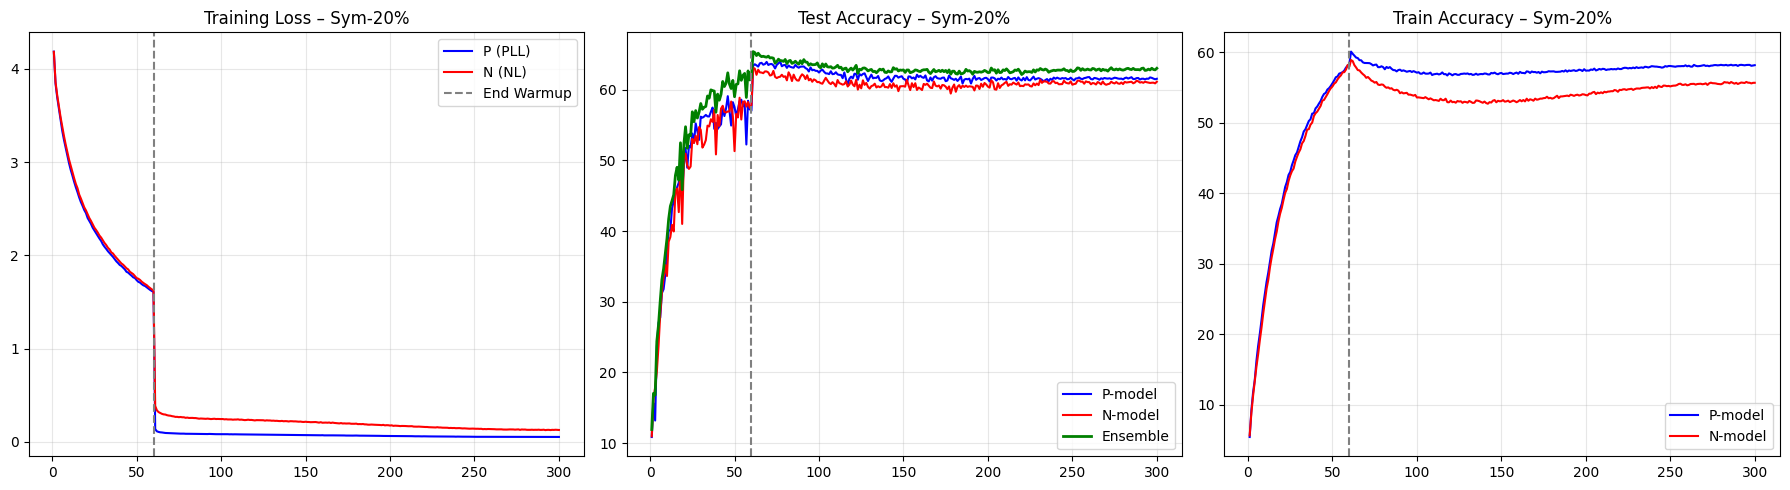

حُفظ: ca2c_v2_Sym_20.png


In [ ]:
def plot_history(history, noise_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['p_train_loss'])+1)
    wu = sum(1 for p in history['phase'] if p == 'Warm-up')

    ax = axes[0]
    ax.plot(epochs, history['p_train_loss'], label='P (PLL)', color='blue')
    ax.plot(epochs, history['n_train_loss'], label='N (NL)',  color='red')
    ax.axvline(wu, color='gray', ls='--', label='End Warmup')
    ax.set_title(f'Training Loss – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, history['p_test_acc'],   label='P-model',  color='blue')
    ax.plot(epochs, history['n_test_acc'],   label='N-model',  color='red')
    ax.plot(epochs, history['ens_test_acc'], label='Ensemble', color='green', lw=2)
    ax.axvline(wu, color='gray', ls='--')
    ax.set_title(f'Test Accuracy – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[2]
    ax.plot(epochs, history['p_train_acc'], label='P-model', color='blue')
    ax.plot(epochs, history['n_train_acc'], label='N-model', color='red')
    ax.axvline(wu, color='gray', ls='--')
    ax.set_title(f'Train Accuracy – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    fn = f'ca2c_v2_{noise_name.replace("%","").replace("-","_")}.png'
    plt.savefig(fn, dpi=150); plt.show()
    print(f'حُفظ: {fn}')

plot_history(history, noise_name)

In [ ]:
# تشغيل التدريب
# غير index: 0=Sym-20%, 1=Sym-40%, 2=Asym-40%

noise_name, noisy_labels = noise_configs[2]

history, p_model, n_model, best_acc = run_ca2c(
    images       = train_images,
    noisy_labels = noisy_labels,
    test_images  = test_images,
    test_labels  = test_labels,
    noise_name   = noise_name,
    num_epochs   = NUM_EPOCHS,
    warm_up      = WARM_UP_EPOCHS,
    k            = K,
    lam          = LAMBDA
)

CIFAR-100 | K=2, λ=0.99


  Ep[  1/300] [Warm-up] Loss P:4.551 N:4.565 | Train P:2.4% N:2.1% | Test P:7.3% N:5.5% Ens:7.5% [Best:7.5%]


  Ep[  2/300] [Warm-up] Loss P:4.390 N:4.427 | Train P:4.1% N:3.5% | Test P:8.3% N:7.1% Ens:9.0% [Best:9.0%]


  Ep[  3/300] [Warm-up] Loss P:4.315 N:4.354 | Train P:5.2% N:4.3% | Test P:11.3% N:9.8% Ens:11.9% [Best:11.9%]


  Ep[  4/300] [Warm-up] Loss P:4.259 N:4.307 | Train P:5.7% N:4.9% | Test P:11.6% N:12.6% Ens:13.2% [Best:13.2%]


...


[Ep280] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.966
Avg NL loss: 0.0732
  Ep[280/300] [Robust ] Loss P:0.048 N:0.130 | Train P:42.9% N:41.3% | Test P:60.1% N:60.4% Ens:61.7% [Best:62.9%]



[Ep290 Robust  ] Candidate Count Stats:
Filled samples: 50000/50000 (100.0%)
Mean: 350000.0, Std: 66520.1, Range: [186060, 531984]
Top-3 classes: [27  7 65] with counts [531984. 496688. 495141.]



[Ep290] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.952
Avg NL loss: 0.0721
  Ep[290/300] [Robust ] Loss P:0.047 N:0.128 | Train P:43.0% N:41.4% | Test P:60.0% N:60.3% Ens:61.5% [Best:62.9%]



[Ep300 Robust  ] Candidate Count Stats:
Filled samples: 50000/50000 (100.0%)
Mean: 360000.0, Std: 68894.8, Range: [190561, 549810]
Top-3 classes: [27  3 65] with counts [549810. 511646. 511480.]



[Ep300] Robust Diagnostics:
Avg complementary labels per sample: 98.0 (target: 98)
Y_soft entropy: 1.939
Avg NL loss: 0.0729
  Ep[300/300] [Robust ] Loss P:0.048 N:0.126 | Train P:43.0% N:41.4% | Test P:60.1% N:60.3% Ens:61.6% [Best:62.9%]

 Done! Best Ensemble = 62.93%



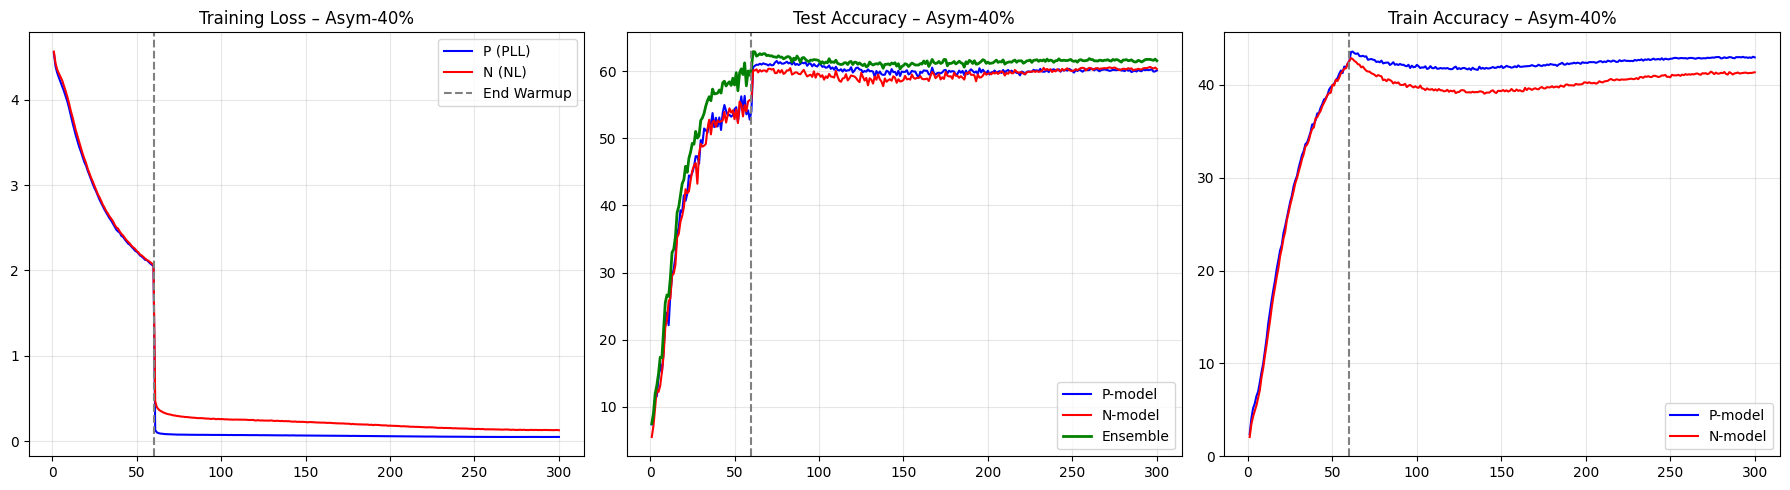

حُفظ: ca2c_v2_Asym_40.png


In [12]:
def plot_history(history, noise_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['p_train_loss'])+1)
    wu = sum(1 for p in history['phase'] if p == 'Warm-up')

    ax = axes[0]
    ax.plot(epochs, history['p_train_loss'], label='P (PLL)', color='blue')
    ax.plot(epochs, history['n_train_loss'], label='N (NL)',  color='red')
    ax.axvline(wu, color='gray', ls='--', label='End Warmup')
    ax.set_title(f'Training Loss – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, history['p_test_acc'],   label='P-model',  color='blue')
    ax.plot(epochs, history['n_test_acc'],   label='N-model',  color='red')
    ax.plot(epochs, history['ens_test_acc'], label='Ensemble', color='green', lw=2)
    ax.axvline(wu, color='gray', ls='--')
    ax.set_title(f'Test Accuracy – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[2]
    ax.plot(epochs, history['p_train_acc'], label='P-model', color='blue')
    ax.plot(epochs, history['n_train_acc'], label='N-model', color='red')
    ax.axvline(wu, color='gray', ls='--')
    ax.set_title(f'Train Accuracy – {noise_name}'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    fn = f'ca2c_v2_{noise_name.replace("%","").replace("-","_")}.png'
    plt.savefig(fn, dpi=150); plt.show()
    print(f'حُفظ: {fn}')

plot_history(history, noise_name)